# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Lina Rahmati
- **Email:** topsmart0@gmail.com
- **ID Dicoding:** CDCC183D6X2710

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Faktor musim dan kondisi cuaca apa saja yang memengaruhi rata-rata jumlah peminjaman sepeda selama periode tahun 2011–2012?
- **Pertanyaan 2:** Seberapa besar perbedaan rata-rata jumlah peminjaman sepeda antara hari kerja dan akhir pekan selama periode tahun 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Pada tahap ini saya lakukan proses pengambilan dataset Bike Sharing yang terdiri dari data harian (day.csv) dan data per jam (hour.csv) dari repository GitHub menggunakan raw URL.

#### Load dataset day.csv

In [20]:
day_df = pd.read_csv('https://raw.githubusercontent.com/linarahmawti/project-akhir-analisis-data/main/day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- melihat 5 baris teratas dari dataset day.csv

#### Load dataset hour.csv

In [21]:
hour_df = pd.read_csv('https://raw.githubusercontent.com/linarahmawti/project-akhir-analisis-data/main/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- melihat 5 baris teratas dari dataset hour.csv

### Assessing Data

#### cek kualitas dataset day_df

In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [6]:
print('Jumlah duplikasi: ', day_df.duplicated().sum())

Jumlah duplikasi:  0


In [7]:
day_df.describe(include='all')

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2012-12-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,NaN,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,NaN,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,NaN,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,NaN,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,NaN,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000


In [8]:
day_df['season'].value_counts()

,count
season,
3,188
2,184
1,181
4,178


In [9]:
day_df['weathersit'].value_counts()

,count
weathersit,
1,463
2,247
3,21


In [10]:
(day_df['casual'] + day_df['registered'] != day_df['cnt']).sum()

np.int64(0)

**Steps to Take:**
- Mengubah tipe data kolom 'dteday' menjadi datetime  
- Melakukan mapping kolom 'season' dan 'weathersit'  
- Memastikan data konsisten dan siap dianalisis

**Insight:** (Opsional)
- dataset 'day_df' memiliki 731 baris dan 16 kolom tanpa missing value maupun data duplikat, data cukup baik untuk dianalisis.
- Kolom 'dteday' masih perlu diubah ke tipe datetime, 'season' dan 'weathersit' perlu dimapping ke kategori yang lebih jelas.
- Data total peminjaman (cnt) sudah konsisten dengan jumlah pengguna casual dan registered.

### Cleaning Data

#### membersihkan day_df

In [26]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [27]:
day_df['season'] = day_df['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

In [28]:
day_df['yr'] = day_df['yr'].map({
    0: 2011,
    1: 2012
})

In [29]:
day_df['mnth'] = day_df['mnth'].map({
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun',
    7:'Jul', 8:'Aug', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
})

In [30]:
day_df['weathersit'] = day_df['weathersit'].map({
    1:'Clear',
    2:'Misty/Cloudy',
    3:'Light Rain/Snow',
    4:'Heavy Rain/Snow'
})

In [31]:
day_df['weekday'] = day_df['weekday'].map({
    0:'Sun', 1:'Mon', 2:'Tue', 3:'Wed',
    4:'Thu', 5:'Fri', 6:'Sat'
})

In [32]:
day_df['workingday'] = day_df['workingday'].map({
    0:'Holiday',
    1:'Working Day'
})

In [33]:
day_df.info()
day_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    object        
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    object        
 7   workingday  731 non-null    object        
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,2011,Jan,0,Sat,Holiday,Misty/Cloudy,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,2011,Jan,0,Sun,Holiday,Misty/Cloudy,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,2011,Jan,0,Mon,Working Day,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,2011,Jan,0,Tue,Working Day,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,2011,Jan,0,Wed,Working Day,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:** (Opsional)
- Kolom 'dteday' dikonversi menjadi tipe datetime untuk mendukung analisis berbasis waktu seperti tren harian atau musiman.
- Kolom kategorikal seperti season dan weathersit direkonstruksi dari nilai numerik menjadi label kategorikal agar lebih mudah diinterpretasikan.
- Data telah dipersiapkan untuk tahap eksplorasi dan visualisasi dengan struktur yang lebih informatif dan mudah dibaca.

## Exploratory Data Analysis (EDA)

### Explore day_df

In [34]:
day_df.info()
day_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    object        
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    object        
 7   workingday  731 non-null    object        
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

,instant,dteday,yr,holiday,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2011.500684,0.028728,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,2011.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2011.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,2012.000000,0.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,2012.000000,0.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,2012.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,0.500342,0.167155,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [61]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


<Axes: >

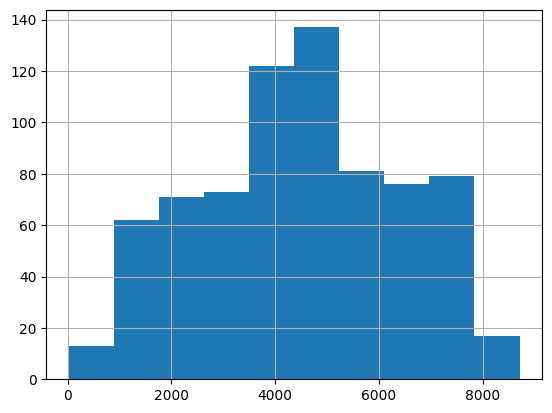

In [65]:
day_df['cnt'].hist()

<Axes: >

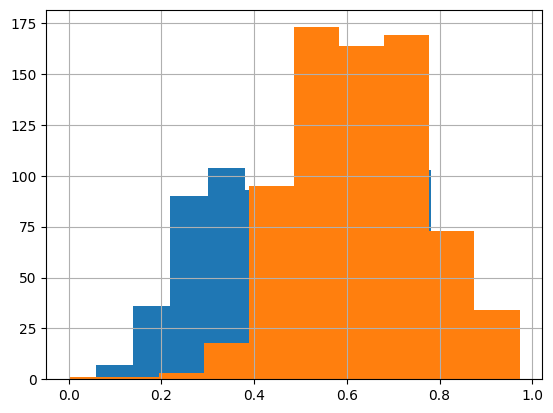

In [66]:
day_df['temp'].hist()
day_df['hum'].hist()

In [62]:
day_df[['cnt','temp','hum','windspeed']].corr()

,cnt,temp,hum,windspeed
cnt,1.000000,0.627494,-0.100659,-0.234545
temp,0.627494,1.000000,0.126963,-0.157944
hum,-0.100659,0.126963,1.000000,-0.248489
windspeed,-0.234545,-0.157944,-0.248489,1.000000


In [36]:
day_df.groupby('season')['cnt'].mean().sort_values()

,cnt
season,
Spring,2604.132597
Winter,4728.162921
Summer,4992.331522
Fall,5644.303191


In [37]:
day_df.groupby('weathersit')['cnt'].mean().sort_values()

,cnt
weathersit,
Light Rain/Snow,1803.285714
Misty/Cloudy,4035.862348
Clear,4876.786177


In [38]:
day_df.groupby('weekday')['cnt'].mean().sort_values()

,cnt
weekday,
Sun,4228.828571
Mon,4338.123810
Tue,4510.663462
Wed,4548.538462
Sat,4550.542857
Thu,4667.259615
Fri,4690.288462


In [63]:
day_df.groupby('workingday')['cnt'].mean()

,cnt
workingday,
Holiday,4330.168831
Working Day,4584.820000


**Insight:** (Opsional)
- Terdapat variasi rata-rata jumlah peminjaman sepeda berdasarkan musim.
- Terdapat perbedaan rata-rata jumlah peminjaman sepeda pada berbagai kondisi cuaca.
- Terdapat perbedaan rata-rata jumlah peminjaman sepeda antara hari kerja dan hari libur.
- Data menunjukkan adanya variasi pola peminjaman sepeda berdasarkan musim, cuaca, dan jenis hari.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

Musim

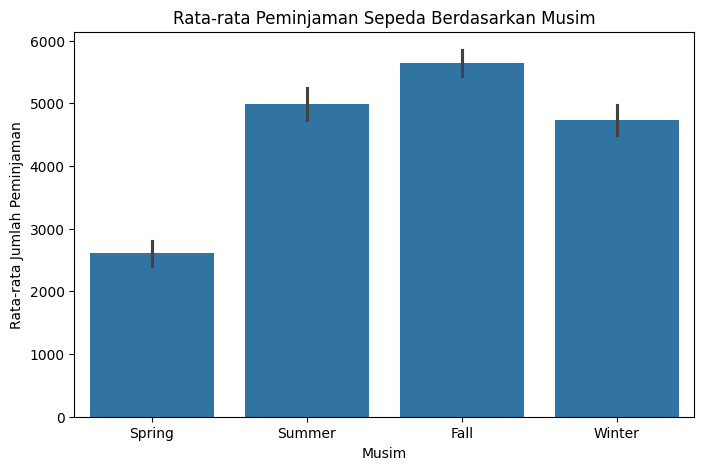

In [48]:
plt.figure(figsize=(8,5))
sns.barplot(data=day_df, x='season', y='cnt', estimator=np.mean)
plt.title('Rata-rata Peminjaman Sepeda Berdasarkan Musim')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Jumlah Peminjaman')
plt.show()

Cuaca

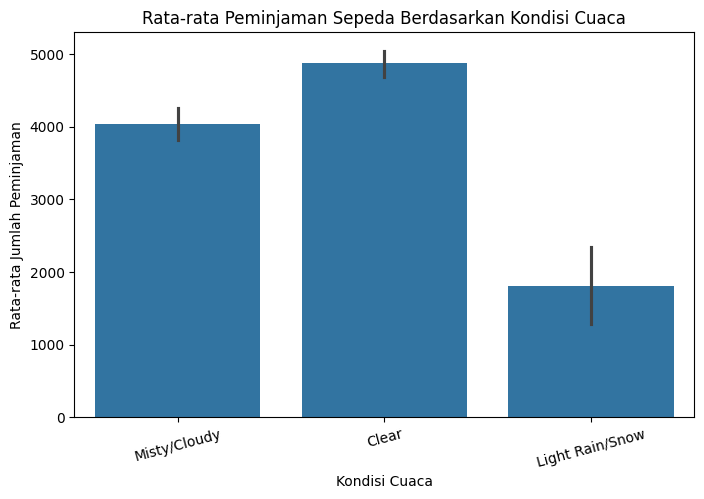

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(data=day_df, x='weathersit', y='cnt', estimator=np.mean)
plt.title('Rata-rata Peminjaman Sepeda Berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Jumlah Peminjaman')
plt.xticks(rotation=15)
plt.show()

### Pertanyaan 2:

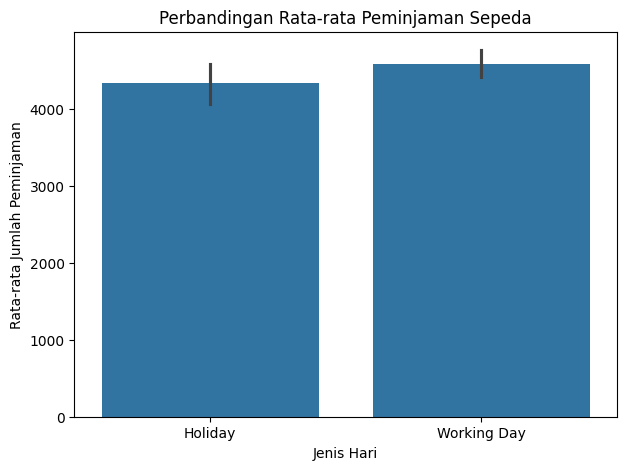

In [53]:
plt.figure(figsize=(7,5))
sns.barplot(data=day_df, x='workingday', y='cnt', estimator=np.mean)
plt.title('Perbandingan Rata-rata Peminjaman Sepeda')
plt.xlabel('Jenis Hari')
plt.ylabel('Rata-rata Jumlah Peminjaman')
plt.show()

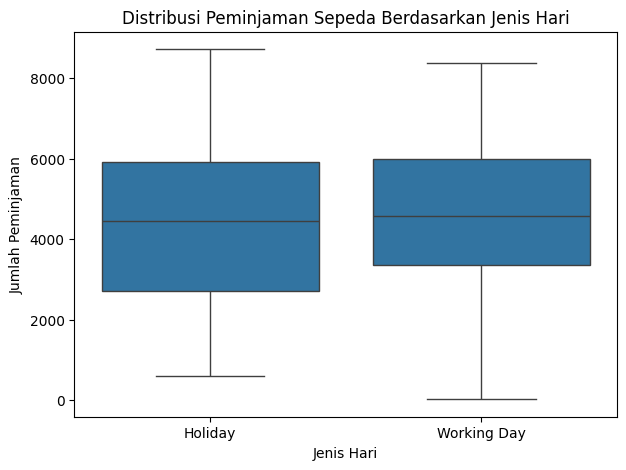

In [54]:
plt.figure(figsize=(7,5))
sns.boxplot(data=day_df, x='workingday', y='cnt')
plt.title('Distribusi Peminjaman Sepeda Berdasarkan Jenis Hari')
plt.xlabel('Jenis Hari')
plt.ylabel('Jumlah Peminjaman')
plt.show()

**Insight:** (Opsional)
- Terdapat perbedaan rata-rata jumlah peminjaman sepeda berdasarkan musim, di mana setiap musim menunjukkan nilai yang berbeda.
- Rata-rata jumlah peminjaman sepeda juga bervariasi berdasarkan kondisi cuaca.
- Terdapat perbedaan rata-rata peminjaman antara hari kerja dan hari libur.
- Distribusi jumlah peminjaman pada hari kerja dan hari libur menunjukkan pola yang relatif mirip dengan adanya beberapa nilai ekstrem (outlier).
- Terdapat variasi pola penggunaan sepeda berdasarkan musim, cuaca, dan jenis hari.

## Analisis Lanjutan (Opsional)

Clustering Sederhana Berdasarkan Tingkat Permintaan

In [55]:
bins = [0, 3000, 6000, day_df['cnt'].max()]
labels = ['Low Demand', 'Medium Demand', 'High Demand']

day_df['demand_category'] = pd.cut(day_df['cnt'], bins=bins, labels=labels)

In [56]:
day_df['demand_category'].value_counts()

,count
demand_category,
Medium Demand,379
High Demand,180
Low Demand,172


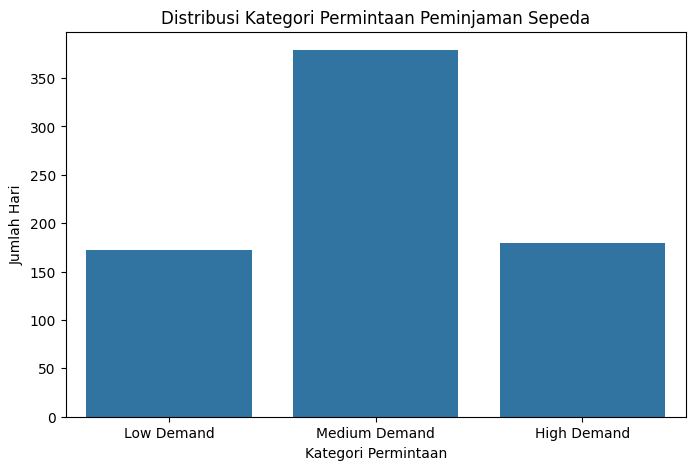

In [57]:
plt.figure(figsize=(8,5))
sns.countplot(data=day_df, x='demand_category', order=['Low Demand','Medium Demand','High Demand'])
plt.title('Distribusi Kategori Permintaan Peminjaman Sepeda')
plt.xlabel('Kategori Permintaan')
plt.ylabel('Jumlah Hari')
plt.show()

In [58]:
day_df.groupby(['demand_category','season'])['cnt'].count()

/tmp/ipykernel_47272/3174377173.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df.groupby(['demand_category','season'])['cnt'].count()


demand_category  season
Low Demand       Fall        4
                 Spring    117
                 Summer     25
                 Winter     26
Medium Demand    Fall      106
                 Spring     59
                 Summer     97
                 Winter    117
High Demand      Fall       78
                 Spring      5
                 Summer     62
                 Winter     35
Name: cnt, dtype: int64

In [59]:
day_df.to_csv("main_data.csv", index=False)

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** musim dan kondisi cuaca memiliki pengaruh terhadap jumlah peminjaman sepeda. Rata-rata peminjaman tertinggi terjadi pada musim Fall dan Summer, serta saat kondisi cuaca cerah. Sebaliknya, jumlah peminjaman menurun pada cuaca buruk dan musim tertentu seperti Spring.
- **Conclusion pertanyaan 2:** rata-rata jumlah peminjaman sepeda pada hari kerja lebih tinggi dibandingkan akhir pekan atau hari libur. Menunjukkan bahwa sepeda lebih banyak digunakan sebagai sarana transportasi untuk aktivitas harian.

**Rekomendasi Action Item:**
- Menambah jumlah sepeda dan ketersediaan stasiun pada musim ramai seperti Fall dan Summer.  
- Memberikan promo atau diskon pada musim sepi dan saat akhir pekan untuk meningkatkan penggunaan.  
- Menyediakan informasi cuaca pada aplikasi agar pengguna dapat merencanakan peminjaman dengan lebih baik.  
- Menyesuaikan operasional dan perawatan sepeda pada hari kerja karena permintaan cenderung lebih tinggi.